In [1]:
# ==========================================
# MACHINE LEARNING TASK 3
# Resume / Candidate Screening System
# PART 1: Load and Explore Dataset
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# Load the dataset
df = pd.read_csv("../data/Resume.csv", encoding="utf-8")

# Display first 5 rows
print("FIRST 5 ROWS:")
display(df.head())

# Dataset shape
print("\nDATASET SHAPE:")
print(df.shape)

# Column names
print("\nCOLUMN NAMES:")
print(df.columns.tolist())

# Dataset information
print("\nDATASET INFORMATION:")
df.info()

# Missing values
print("\nMISSING VALUES:")
print(df.isnull().sum())

# Check unique resume categories
print("\nRESUME CATEGORIES:")
print(df["Category"].value_counts())

# Display one sample resume
print("\nSAMPLE RESUME:")
print(df["Resume_str"].iloc[0][:1000])

FIRST 5 ROWS:


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR



DATASET SHAPE:
(2484, 4)

COLUMN NAMES:
['ID', 'Resume_str', 'Resume_html', 'Category']

DATASET INFORMATION:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB

MISSING VALUES:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

RESUME CATEGORIES:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115

In [2]:
# ==========================================
# PART 2: RESUME SCREENING AND CANDIDATE RANKING
# ==========================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ------------------------------------------
# 1. CLEAN RESUME TEXT
# ------------------------------------------

def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z+#.\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


df["Clean_Resume"] = df["Resume_str"].fillna("").apply(clean_text)

print("Resume text cleaned successfully!")

# ------------------------------------------
# 2. DEFINE JOB DESCRIPTION
# ------------------------------------------

job_role = "Machine Learning Engineer"

job_description = """
We are looking for a Machine Learning Engineer with strong knowledge
of Python, Machine Learning, Deep Learning, Data Science and
Natural Language Processing.

Required skills include Python, Pandas, NumPy, Scikit-learn,
TensorFlow, PyTorch, Machine Learning, Deep Learning,
NLP, Data Analysis, SQL, Data Visualization and Git.
"""

print("\nTARGET JOB ROLE:")
print(job_role)

print("\nJOB DESCRIPTION:")
print(job_description)

# ------------------------------------------
# 3. SKILL LIST
# ------------------------------------------

skills = [
    "python",
    "machine learning",
    "deep learning",
    "data science",
    "nlp",
    "natural language processing",
    "pandas",
    "numpy",
    "scikit-learn",
    "tensorflow",
    "pytorch",
    "sql",
    "data analysis",
    "data visualization",
    "matplotlib",
    "git",
    "keras"
]

# ------------------------------------------
# 4. SKILL EXTRACTION FUNCTION
# ------------------------------------------

def extract_skills(text):

    text = str(text).lower()

    found_skills = []

    for skill in skills:
        if skill in text:
            found_skills.append(skill)

    return list(set(found_skills))


# Extract skills from each resume
df["Extracted_Skills"] = df["Clean_Resume"].apply(extract_skills)

print("\nSAMPLE EXTRACTED SKILLS:")
display(
    df[
        ["Category", "Extracted_Skills"]
    ].head(10)
)

# ------------------------------------------
# 5. JOB DESCRIPTION SKILLS
# ------------------------------------------

job_skills = extract_skills(job_description)

print("\nREQUIRED JOB SKILLS:")
print(job_skills)

# ------------------------------------------
# 6. TF-IDF + COSINE SIMILARITY
# ------------------------------------------

# Combine job description with resumes
documents = [job_description] + df["Clean_Resume"].tolist()

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

tfidf_matrix = tfidf.fit_transform(documents)

# Job description vector
job_vector = tfidf_matrix[0]

# Resume vectors
resume_vectors = tfidf_matrix[1:]

# Calculate similarity scores
similarity_scores = cosine_similarity(
    resume_vectors,
    job_vector
).flatten()

# Add score to dataframe
df["Similarity_Score"] = similarity_scores * 100

# ------------------------------------------
# 7. MATCHED AND MISSING SKILLS
# ------------------------------------------

def get_matched_skills(resume_skills):

    return list(
        set(resume_skills)
        .intersection(set(job_skills))
    )


def get_missing_skills(resume_skills):

    return list(
        set(job_skills)
        - set(resume_skills)
    )


df["Matched_Skills"] = df["Extracted_Skills"].apply(
    get_matched_skills
)

df["Missing_Skills"] = df["Extracted_Skills"].apply(
    get_missing_skills
)

# Count matched skills
df["Matched_Skill_Count"] = df["Matched_Skills"].apply(len)

# ------------------------------------------
# 8. FINAL CANDIDATE SCORE
# ------------------------------------------

# Combine similarity score and skill match score
df["Final_Score"] = (
    df["Similarity_Score"] * 0.7
    +
    (df["Matched_Skill_Count"] / max(len(job_skills), 1))
    * 100
    * 0.3
)

# ------------------------------------------
# 9. RANK CANDIDATES
# ------------------------------------------

ranked_candidates = df.sort_values(
    by="Final_Score",
    ascending=False
).reset_index(drop=True)

ranked_candidates["Rank"] = (
    ranked_candidates.index + 1
)

# ------------------------------------------
# 10. SHOW TOP 10 CANDIDATES
# ------------------------------------------

print("\n==========================================")
print("TOP 10 CANDIDATES FOR MACHINE LEARNING ENGINEER")
print("==========================================\n")

display(
    ranked_candidates[
        [
            "Rank",
            "Category",
            "Similarity_Score",
            "Matched_Skill_Count",
            "Matched_Skills",
            "Missing_Skills",
            "Final_Score"
        ]
    ].head(10)
)

print("\nResume screening and ranking completed successfully!")

Resume text cleaned successfully!

TARGET JOB ROLE:
Machine Learning Engineer

JOB DESCRIPTION:

We are looking for a Machine Learning Engineer with strong knowledge
of Python, Machine Learning, Deep Learning, Data Science and
Natural Language Processing.

Required skills include Python, Pandas, NumPy, Scikit-learn,
TensorFlow, PyTorch, Machine Learning, Deep Learning,
NLP, Data Analysis, SQL, Data Visualization and Git.


SAMPLE EXTRACTED SKILLS:


,Category,Extracted_Skills
0,HR,[data analysis]
1,HR,[git]
2,HR,[]
3,HR,[]
4,HR,[]
5,HR,[]
6,HR,[]
7,HR,[]
8,HR,[]
9,HR,[]



REQUIRED JOB SKILLS:
['numpy', 'scikit-learn', 'sql', 'data analysis', 'nlp', 'git', 'tensorflow', 'machine learning', 'pytorch', 'data science', 'deep learning', 'data visualization', 'natural language processing', 'python', 'pandas']

TOP 10 CANDIDATES FOR MACHINE LEARNING ENGINEER



,Rank,Category,Similarity_Score,Matched_Skill_Count,Matched_Skills,Missing_Skills,Final_Score
0,1,ENGINEERING,28.654404,6,"[sql, data analysis, machine learning, data vi...","[numpy, scikit-learn, nlp, git, tensorflow, py...",32.058083
1,2,CONSULTANT,26.220843,6,"[sql, data analysis, machine learning, data sc...","[numpy, scikit-learn, nlp, git, tensorflow, py...",30.354590
2,3,AUTOMOBILE,18.625669,7,"[numpy, sql, data analysis, data science, data...","[scikit-learn, nlp, git, tensorflow, machine l...",27.037968
3,4,AGRICULTURE,20.854598,5,"[sql, tensorflow, data visualization, python, ...","[numpy, scikit-learn, data analysis, nlp, git,...",24.598218
4,5,BANKING,24.769499,3,"[machine learning, sql, python]","[numpy, scikit-learn, data analysis, nlp, git,...",23.338649
5,6,AUTOMOBILE,19.071971,4,"[machine learning, sql, python, data analysis]","[numpy, scikit-learn, nlp, git, tensorflow, py...",21.350380
6,7,AGRICULTURE,18.673659,4,"[data science, sql, python, pandas]","[numpy, scikit-learn, data analysis, nlp, git,...",21.071561
7,8,ENGINEERING,8.415648,6,"[sql, git, tensorflow, machine learning, pytho...","[numpy, scikit-learn, data analysis, nlp, pyto...",17.890953
8,9,ARTS,25.440082,0,[],"[numpy, scikit-learn, sql, data analysis, nlp,...",17.808058
9,10,DIGITAL-MEDIA,14.076034,3,"[git, sql, python]","[numpy, scikit-learn, data analysis, nlp, tens...",15.853224



Resume screening and ranking completed successfully!


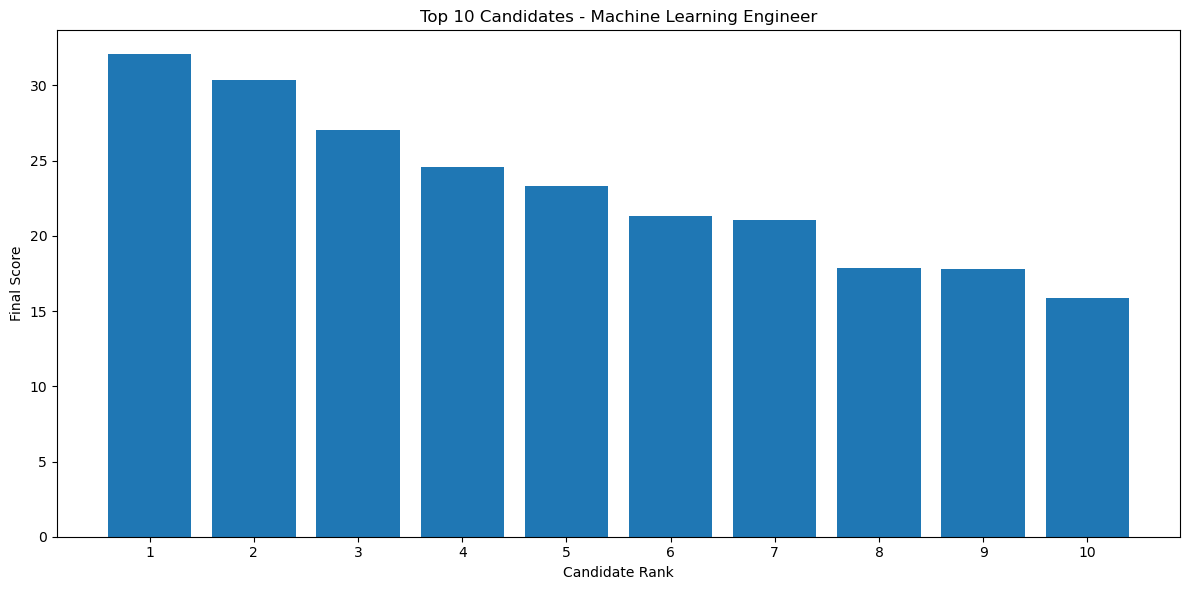

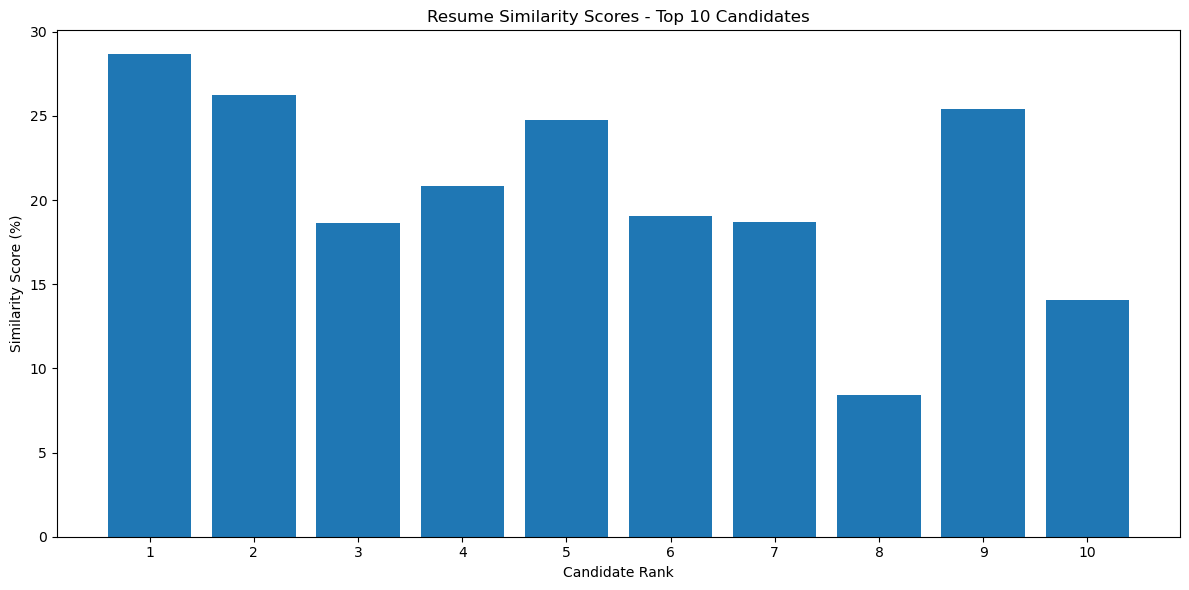

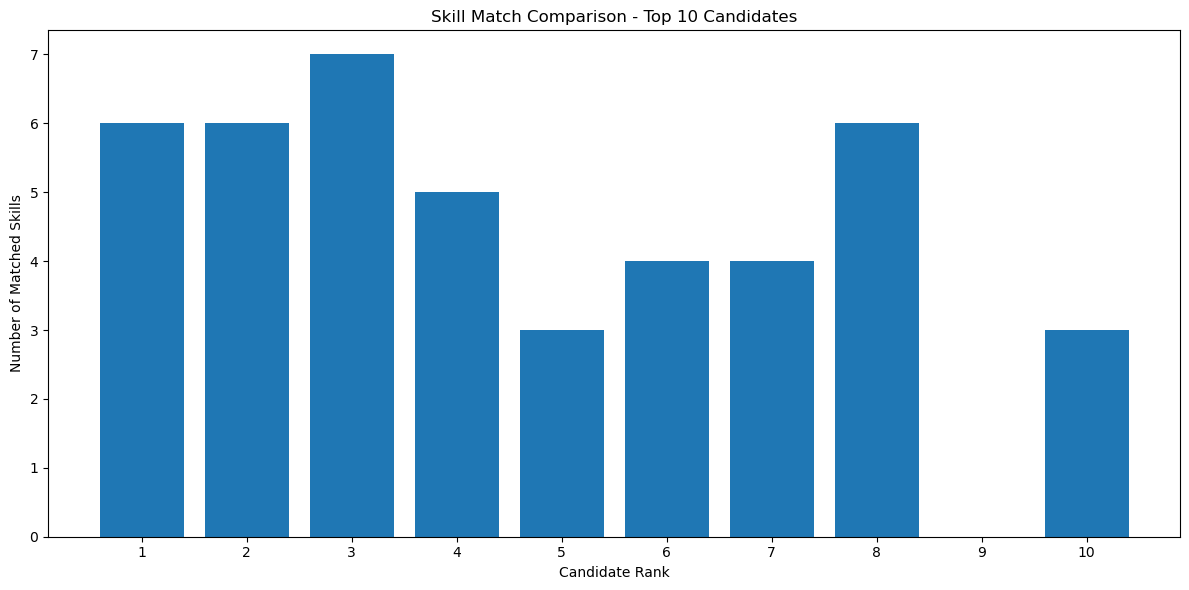

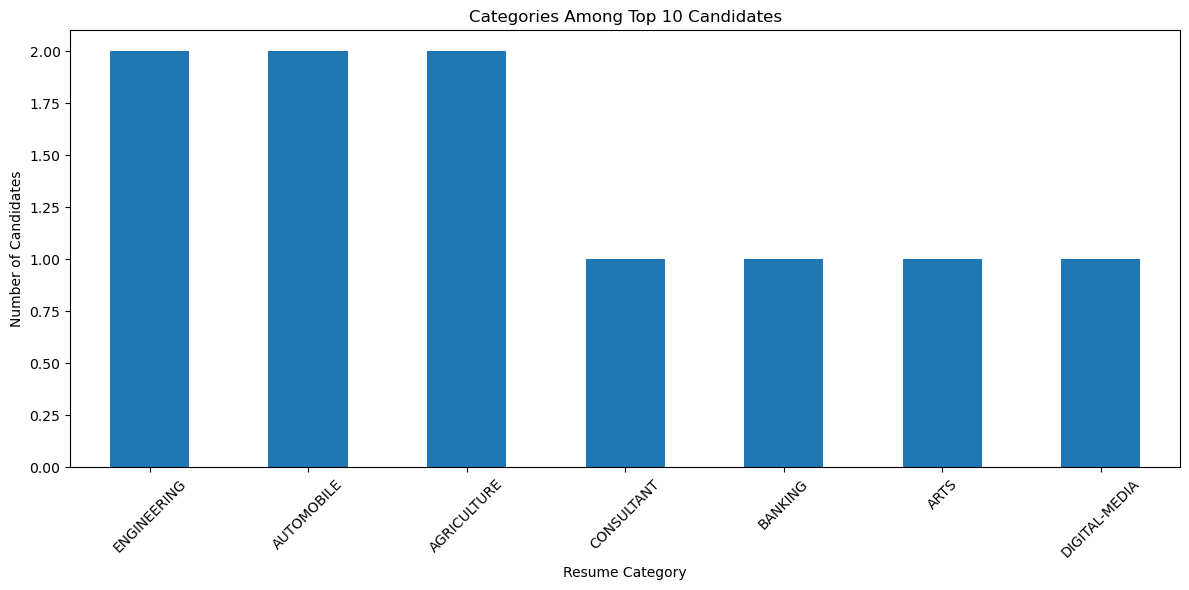

TOP 5 CANDIDATE DETAILS

RANK: 1
Resume Category: ENGINEERING
Final Score: 32.06%
Similarity Score: 28.65%
Matched Skills: sql, data analysis, machine learning, data visualization, python, pandas
Missing Skills: numpy, scikit-learn, nlp, git, tensorflow, pytorch, data science, deep learning, natural language processing
------------------------------------------------------------

RANK: 2
Resume Category: CONSULTANT
Final Score: 30.35%
Similarity Score: 26.22%
Matched Skills: sql, data analysis, machine learning, data science, data visualization, python
Missing Skills: numpy, scikit-learn, nlp, git, tensorflow, pytorch, deep learning, natural language processing, pandas
------------------------------------------------------------

RANK: 3
Resume Category: AUTOMOBILE
Final Score: 27.04%
Similarity Score: 18.63%
Matched Skills: numpy, sql, data analysis, data science, data visualization, python, pandas
Missing Skills: scikit-learn, nlp, git, tensorflow, machine learning, pytorch, deep lea

In [3]:
# ==========================================
# PART 3: VISUALIZATION AND FINAL RESULTS
# ==========================================

# ------------------------------------------
# 1. TOP 10 CANDIDATES VISUALIZATION
# ------------------------------------------

top_10 = ranked_candidates.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_10["Rank"].astype(str),
    top_10["Final_Score"]
)

plt.xlabel("Candidate Rank")
plt.ylabel("Final Score")
plt.title("Top 10 Candidates - Machine Learning Engineer")

plt.tight_layout()

plt.savefig(
    "../images/top_10_candidates.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------
# 2. TOP 10 SIMILARITY SCORES
# ------------------------------------------

plt.figure(figsize=(12, 6))

plt.bar(
    top_10["Rank"].astype(str),
    top_10["Similarity_Score"]
)

plt.xlabel("Candidate Rank")
plt.ylabel("Similarity Score (%)")
plt.title("Resume Similarity Scores - Top 10 Candidates")

plt.tight_layout()

plt.savefig(
    "../images/resume_similarity_scores.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------
# 3. MATCHED SKILLS COMPARISON
# ------------------------------------------

plt.figure(figsize=(12, 6))

plt.bar(
    top_10["Rank"].astype(str),
    top_10["Matched_Skill_Count"]
)

plt.xlabel("Candidate Rank")
plt.ylabel("Number of Matched Skills")
plt.title("Skill Match Comparison - Top 10 Candidates")

plt.tight_layout()

plt.savefig(
    "../images/skill_match_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------
# 4. CANDIDATE CATEGORY DISTRIBUTION
# ------------------------------------------

plt.figure(figsize=(12, 6))

top_10["Category"].value_counts().plot(
    kind="bar"
)

plt.xlabel("Resume Category")
plt.ylabel("Number of Candidates")
plt.title("Categories Among Top 10 Candidates")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../images/top_candidate_categories.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------
# 5. DETAILED TOP 5 CANDIDATES
# ------------------------------------------

print("==========================================")
print("TOP 5 CANDIDATE DETAILS")
print("==========================================")

for i, row in ranked_candidates.head(5).iterrows():

    print(f"\nRANK: {row['Rank']}")
    print(f"Resume Category: {row['Category']}")
    print(f"Final Score: {row['Final_Score']:.2f}%")
    print(f"Similarity Score: {row['Similarity_Score']:.2f}%")
    print(f"Matched Skills: {', '.join(row['Matched_Skills'])}")
    print(f"Missing Skills: {', '.join(row['Missing_Skills'])}")
    print("-" * 60)


# ------------------------------------------
# 6. SAVE FINAL RESULTS
# ------------------------------------------

results = ranked_candidates[
    [
        "Rank",
        "Category",
        "Similarity_Score",
        "Extracted_Skills",
        "Matched_Skills",
        "Missing_Skills",
        "Matched_Skill_Count",
        "Final_Score"
    ]
]

results.to_csv(
    "../data/candidate_ranking_results.csv",
    index=False
)

print("\n==========================================")
print("PROJECT COMPLETED SUCCESSFULLY!")
print("==========================================")

print("\nFiles generated:")
print("- top_10_candidates.png")
print("- resume_similarity_scores.png")
print("- skill_match_comparison.png")
print("- top_candidate_categories.png")
print("- candidate_ranking_results.csv")